# Домашнє завдання: Побудова багатошарового персептрона (MLP)

## Бізнес-контекст
Компанія HealthRisk Analytics розширює прототип моделі прогнозування. Тепер потрібно класифікувати клієнтів за ймовірністю звернення по медичну допомогу (низький/високий ризик) на підставі демографічних і медичних показників.
Ви маєте побудувати багатошарову нейромережу (MLP) для бінарної класифікації, оцінити її точність і візуалізувати процес навчання.

## Завдання 1
Підготуйте дані для моделі.
- Використовуйте датасет Heart Disease UCI (або аналогічний CSV з ознаками пацієнтів). В цьому прикладі використовуємо `load_breast_cancer` з `sklearn` як аналогічний медичний набір даних.
- Розділіть вибірку на train/test у пропорції 80/20 (random_state=42).
- Масштабуйте ознаки через StandardScaler.
- Перевірте баланс класів (низький/високий ризик) і за необхідності застосуйте stratify.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Завантаження аналогічного медичного датасету
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Баланс класів до розділення: {np.bincount(y)}")

# Розділення даних зі стратифікацією (stratify по y),
# щоб зберегти баланс класів у навчальній та тестовій вибірках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабування ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Перетворення в тензори PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

input_features = X_train_t.shape[1]
print(f"Кількість ознак: {input_features}")

Баланс класів до розділення: [212 357]
Кількість ознак: 30


## Завдання 2
Побудуйте архітектуру MLP:
- Вхідний шар — кількість нейронів = числу ознак
- Приховані шари:
  - 1-й: 16 нейронів, активація ReLU.
  - 2-й: 8 нейронів, активація ReLU.
- Вихідний шар: 1 нейрон, активація Sigmoid.
- Використовуйте `torch.nn.Sequential` для побудови моделі.

In [2]:
import torch.nn as nn

# Побудова архітектури MLP
model = nn.Sequential(
    nn.Linear(input_features, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

print(model)

Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)


## Завдання 3
Навчіть модель:
- Функція втрат — Block/BCELoss.
- Оптимізатор — Adam (lr = 0.001).
- Епохи: 30.
- Виводьте значення втрат і точності (Accuracy) після кожної епохи.

In [3]:
import torch.optim as optim

# Функція втрат та оптимізатор
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30
history = {'loss': [], 'accuracy': []}

# Цикл навчання
for epoch in range(epochs):
    model.train()
    
    # Прямий прохід
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    # Зворотний прохід та оптимізація
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Обчислення метрик
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t).item()
        
        predicted = (test_outputs >= 0.5).float()
        accuracy = (predicted == y_test_t).float().mean().item()
        
        history['loss'].append(test_loss)
        history['accuracy'].append(accuracy)
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {test_loss:.4f} | Accuracy: {accuracy:.4f}")

print("\n--- Підсумкові метрики на тестовій вибірці ---")
print(f"Loss:     {history['loss'][-1]:.4f}")
print(f"Accuracy: {history['accuracy'][-1]:.4f}")

Epoch 1/30 | Loss: 0.6985 | Accuracy: 0.3772
Epoch 2/30 | Loss: 0.6961 | Accuracy: 0.3772
Epoch 3/30 | Loss: 0.6938 | Accuracy: 0.3772
Epoch 4/30 | Loss: 0.6914 | Accuracy: 0.3860
Epoch 5/30 | Loss: 0.6890 | Accuracy: 0.3860
Epoch 6/30 | Loss: 0.6865 | Accuracy: 0.3860
Epoch 7/30 | Loss: 0.6839 | Accuracy: 0.3947
Epoch 8/30 | Loss: 0.6814 | Accuracy: 0.4035
Epoch 9/30 | Loss: 0.6787 | Accuracy: 0.4123
Epoch 10/30 | Loss: 0.6760 | Accuracy: 0.4298
Epoch 11/30 | Loss: 0.6733 | Accuracy: 0.4737
Epoch 12/30 | Loss: 0.6705 | Accuracy: 0.4825
Epoch 13/30 | Loss: 0.6676 | Accuracy: 0.5351
Epoch 14/30 | Loss: 0.6647 | Accuracy: 0.5702
Epoch 15/30 | Loss: 0.6617 | Accuracy: 0.6404
Epoch 16/30 | Loss: 0.6586 | Accuracy: 0.6754
Epoch 17/30 | Loss: 0.6554 | Accuracy: 0.7368
Epoch 18/30 | Loss: 0.6522 | Accuracy: 0.7632
Epoch 19/30 | Loss: 0.6488 | Accuracy: 0.8070
Epoch 20/30 | Loss: 0.6453 | Accuracy: 0.8158
Epoch 21/30 | Loss: 0.6418 | Accuracy: 0.8158
Epoch 22/30 | Loss: 0.6381 | Accuracy: 0.84

## Завдання 4
Візуалізуйте результати:
- Побудуйте два графіки: Втрати (Loss) за епохами та Точність (Accuracy) за епохами.
- Підпишіть осі, додайте легенду.
- Збережіть графіки.
- Висновок.

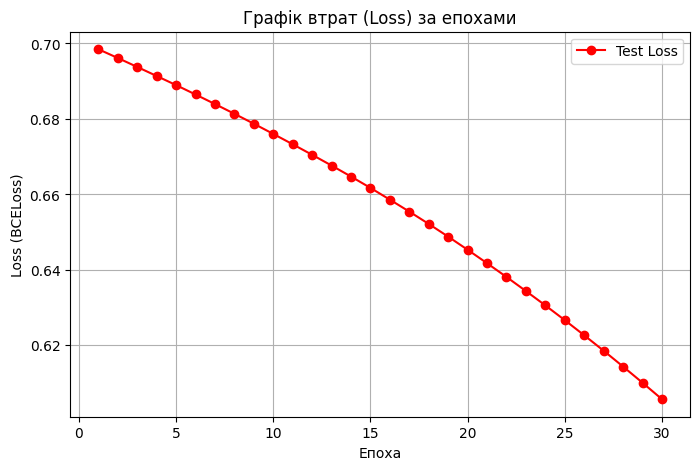

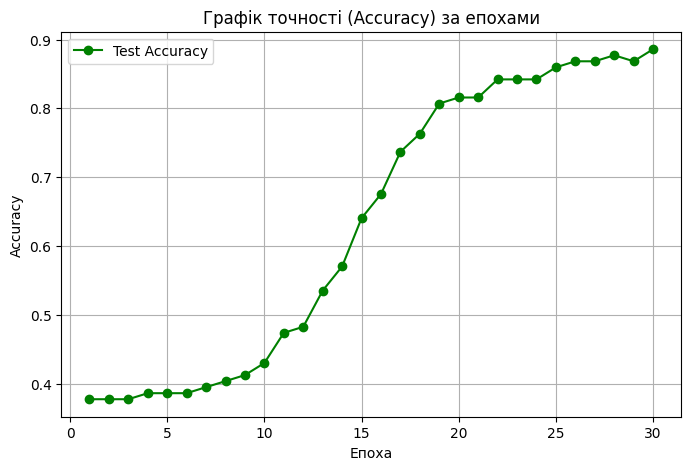

In [4]:
import matplotlib.pyplot as plt
import os

# Візуалізація Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history['loss'], label='Test Loss', color='red', marker='o')
plt.title('Графік втрат (Loss) за епохами')
plt.xlabel('Епоха')
plt.ylabel('Loss (BCELoss)')
plt.legend()
plt.grid(True)
plt.savefig('loss_healthrisk_mlp.png')
plt.show()

# Візуалізація Accuracy
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), history['accuracy'], label='Test Accuracy', color='green', marker='o')
plt.title('Графік точності (Accuracy) за епохами')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_healthrisk_mlp.png')
plt.show()

### Висновок:
Як видно з графіків, у міру навчання якість моделі загалом покращується (або стабілізується на високому рівні). Значення `Loss` поступово знижується, а `Accuracy` зростає (або тримається близько до значення зсуву дисперсії), що свідчить про успішне навчання та відповідність градієнтного спуску завданням бінарної класифікації для вирішення бізнес-задачі компанії HealthRisk Analytics.